# <span style="color:#0f766e; font-weight:700;">Analiza Danych (Python) - Lekcja 5</span>

W tej lekcji skupiamy się wyłącznie na wizualizacji danych.
Celem jest przejście od podstawowych wykresów w Pythonie do bardziej rozbudowanych układów typu dashboard i pairplot.


# <span style="color:#0f766e; font-weight:700;">1. Dlaczego wizualizacja jest kluczowa?</span>

Wizualizacja danych nie jest dodatkiem do analizy. To jedna z jej podstawowych części.

Dobrze przygotowany wykres pomaga:
- szybciej zobaczyć wzorce, trendy i odchylenia,
- zauważyć wartości odstające i problemy z jakością danych,
- porównać grupy bez czytania długich tabel,
- opowiedzieć historię danych osobom nietechnicznym,
- zweryfikować, czy liczby z tabeli rzeczywiście znaczą to, co nam się wydaje.

W praktyce bardzo często kolejność pracy wygląda tak:
1. przygotowujemy dane,
2. liczymy podstawowe statystyki,
3. rysujemy wykres,
4. wracamy do danych i poprawiamy pytanie badawcze,
5. budujemy lepszą wizualizację.

To znaczy, że wykres nie jest tylko "ładnym obrazkiem".
Jest narzędziem myślenia analitycznego.


# <span style="color:#0f766e; font-weight:700;">2. Jak dobrać typ wykresu do pytania?</span>

Najpierw pytanie, potem wykres.

Typowe mapowanie wygląda tak:

| Pytanie analityczne | Najlepszy wykres |
| --- | --- |
| Ile obserwacji jest w każdej kategorii? | `countplot()` |
| Jak porównać gotowe wartości między kategoriami? | `barplot()` |
| Jak wygląda rozkład jednej zmiennej liczbowej? | `histplot()` |
| Jak porównać rozkład liczby między grupami? | `boxplot()`, `violinplot()` |
| Czy dwie zmienne liczbowe są ze sobą powiązane? | `scatterplot()` |
| Jak zmienia się wskaźnik w czasie lub w kolejności? | `lineplot()` |
| Jak pokazać tabelę wartości w formie mapy? | `heatmap()` |
| Jak szybko obejrzeć wiele relacji liczbowych naraz? | `pairplot()` |

Najczęstszy błąd początkujących:
- rysowanie pierwszego wykresu, który "wychodzi",
- zamiast rysowania wykresu, który odpowiada na konkretne pytanie.


# <span style="color:#0f766e; font-weight:700;">3. Matplotlib i seaborn - kto za co odpowiada?</span>

W tej lekcji będziemy używać dwóch bibliotek:

`matplotlib`
- daje pełną kontrolę nad figurą,
- odpowiada za rozmiar wykresu, układ paneli, tytuły, osie, podpisy i końcowe wyświetlenie.

`seaborn`
- buduje właściwe wykresy statystyczne,
- ma wygodny interfejs oparty o `DataFrame`,
- pozwala szybciej tworzyć estetyczne wykresy analityczne.

Najczęstszy schemat pracy:
1. `plt.figure(...)` albo `plt.subplots(...)`
2. `sns.some_plot(...)`
3. `plt.title(...)`, `plt.xlabel(...)`, `plt.ylabel(...)`
4. `plt.tight_layout()`
5. `plt.show()`


# <span style="color:#0f766e; font-weight:700;">4. Ustawienia globalne i styl wykresów</span>

Na początku sesji zwykle ustawiamy styl całej lekcji:

`sns.set_theme(style='whitegrid', palette='Set2')`

Co oznaczają parametry?
- `style='whitegrid'` - jasne tło z delikatną siatką; bardzo dobre do wykresów analitycznych.
- `palette='Set2'` - domyślna paleta kolorów dla wielu kategorii.

Gdy pracujesz z wykresami:
- trzymaj spójny styl w całym notebooku,
- nie mieszaj przypadkowych kolorów,
- unikaj zbyt ciężkich teł i agresywnych palet.


# <span style="color:#0f766e; font-weight:700;">5. Parametry `matplotlib`, które musisz znać</span>

Podstawowe elementy figury:

`plt.figure(figsize=(8, 4))`
- `figsize=(szerokość, wysokość)` ustawia rozmiar wykresu.

`plt.subplots(nrows=1, ncols=2, figsize=(14, 4), sharey=False)`
- `nrows` - liczba wierszy paneli,
- `ncols` - liczba kolumn paneli,
- `figsize` - rozmiar całej figury,
- `sharey=False` - każdy panel ma własną oś Y,
- `sharey=True` - panele współdzielą oś Y, więc łatwiej porównać poziom wartości.

Opisy:
- `plt.title('...')` - tytuł wykresu,
- `plt.xlabel('...')` - podpis osi X,
- `plt.ylabel('...')` - podpis osi Y,
- `plt.xticks(rotation=45)` - obrót etykiet osi X,
- `plt.tight_layout()` - poprawa układu,
- `plt.show()` - wyświetlenie wykresu.

W dashboardach pracujemy na obiektach osi:
- `ax=axes[0]` - wykres trafia do konkretnego panelu,
- `axes[0].set_title('...')`
- `axes[0].set_xlabel('...')`
- `axes[0].set_ylabel('...')`
- `axes[0].tick_params(axis='x', rotation=45)`
- `axes[1].legend(title='origin')`

Dodatkowo przy bardziej złożonych figurach:
- `fig.suptitle('...', y=1.02)` - wspólny tytuł dla całej figury; parametr `y` podnosi tytuł wyżej,
- `fig.subplots_adjust(top=0.95)` - zostawia miejsce nad wykresem, żeby tytuł się nie uciął.


# <span style="color:#0f766e; font-weight:700;">6. Wykresy kategoryczne: `countplot()` i `barplot()`</span>

`sns.countplot(data=..., x=..., order=..., color=...)`
- `data=` - tabela źródłowa,
- `x=` - zmienna kategoryczna,
- `order=` - kolejność kategorii,
- `color=` - jeden kolor dla wszystkich słupków.

Kiedy używać?
- gdy interesuje Cię liczba rekordów w każdej kategorii.

`sns.barplot(data=..., x=..., y=..., color=..., errorbar=None)`
- `data=` - tabela źródłowa,
- `x=` i `y=` - kategoria i wartość,
- `color=` - kolor słupków,
- `errorbar=None` - wyłącza domyślne przedziały błędu.

Kiedy używać?
- gdy masz już gotowe agregacje, np. średnią, medianę, liczbę lotów.

Ważna różnica:
- `countplot()` liczy sam,
- `barplot()` zwykle rysuje wartości, które wcześniej przygotowaliśmy.


# <span style="color:#0f766e; font-weight:700;">7. Rozkłady: `histplot()`, `boxplot()`, `violinplot()`</span>

`sns.histplot(data=..., x=..., bins=30, kde=True, color=...)`
- `bins=` - liczba koszy histogramu,
- `kde=True` - dodatkowa krzywa gęstości,
- dobry wybór do jednej zmiennej liczbowej.

`sns.boxplot(data=..., x=..., y=..., color=...)`
- pokazuje medianę, kwartyle i wartości odstające,
- świetny do porównań między grupami.

`sns.violinplot(data=..., x=..., y=..., inner='quartile', color=...)`
- pokazuje kształt całego rozkładu,
- `inner='quartile'` dodaje kwartyle wewnątrz "skrzypiec".

Dobra praktyka:
- histogram do jednej zmiennej,
- boxplot do szybkiego porównania grup,
- violinplot, gdy chcesz zobaczyć pełniejszy kształt rozkładu.


# <span style="color:#0f766e; font-weight:700;">8. Relacje i trendy: `scatterplot()` oraz `lineplot()`</span>

`sns.scatterplot(data=..., x=..., y=..., hue=..., alpha=...)`
- `x=` i `y=` - dwie zmienne liczbowe,
- `hue=` - dodatkowa kategoria rozróżniana kolorem,
- `alpha=` - przezroczystość punktów.

`sns.lineplot(data=..., x=..., y=..., hue=..., marker='o')`
- `x=` - zwykle czas albo uporządkowana kategoria,
- `y=` - wskaźnik liczbowy,
- `hue=` - osobna linia dla kategorii,
- `marker='o'` - widoczne punkty serii.

Przy dużych danych:
- często warto użyć `sample(..., random_state=42)` przed `scatterplot()`,
- `random_state=42` daje powtarzalny wynik.
- jeśli nie masz pewności, czy tabela ma wystarczająco dużo rekordów, użyj
  `sample(min(2000, len(df)), random_state=42)`.
- `len(df)` zwraca liczbę wierszy,
- `min(...)` wybiera mniejszą z dwóch wartości i chroni przed błędem próbkowania.


# <span style="color:#0f766e; font-weight:700;">9. Tabele przestawne i heatmapy</span>

Bardzo częsty schemat pracy:

`pivot_table(index=..., columns=..., values=..., aggfunc='mean')`
- `index=` - co trafia do wierszy,
- `columns=` - co trafia do kolumn,
- `values=` - jaka zmienna ma wypełnić komórki,
- `aggfunc='mean'` - jak liczyć wartość w komórce.

Potem:

`sns.heatmap(data=..., annot=True, fmt='.1f', cmap='YlGnBu', linewidths=0.5)`
- `annot=True` - wpisuje liczby do komórek,
- `fmt='.1f'` - format liczb,
- `cmap=` - paleta kolorów,
- `linewidths=0.5` - cienkie linie między komórkami.

Heatmapa jest dobra, gdy chcesz porównać wiele grup jednocześnie
i zależy Ci na macierzy wartości, a nie pojedynczym szeregu.


# <span style="color:#0f766e; font-weight:700;">10. Wykresy bardziej zaawansowane: `pairplot()` i dashboardy</span>

`sns.pairplot(data=..., vars=[...], hue=..., corner=True)`
- `vars=[...]` - lista zmiennych liczbowych,
- `hue=` - kolor dla kategorii,
- `corner=True` - pokazuje tylko dolny trójkąt macierzy.

Po zbudowaniu pairplota często wykonujemy jeszcze dwa kroki:
- `pair_grid.fig.suptitle('...', y=1.02)` - dodaje wspólny tytuł nad całą siatką,
- `pair_grid.fig.subplots_adjust(top=0.95)` - zostawia miejsce nad wykresem.

To dobry wykres do eksploracji:
- korelacji,
- kształtu rozkładów,
- różnic między kategoriami.

Dashboard to kilka wykresów w jednej figurze:
- używamy `plt.subplots(...)`,
- każdy wykres dostaje własny `ax=...`,
- podpisy ustawiamy już na poziomie osi, np. `axes[0].set_title(...)`.

To bardzo ważna umiejętność:
- pojedynczy wykres odpowiada na jedno pytanie,
- dashboard pozwala połączyć kilka perspektyw w jednym miejscu.


# <span style="color:#0f766e; font-weight:700;">11. Operacje pomocnicze przed rysowaniem</span>

Zanim narysujesz wykres, często trzeba przygotować dane.

W tej lekcji używamy między innymi:
- `query("...")` - czytelne filtrowanie danych; warunek zapisujemy jako tekst,
- `dropna(subset=[...])` - usuwanie braków tylko w wybranych kolumnach,
- `groupby(..., as_index=False).agg(...)` - agregacje do wykresów kategorycznych i liniowych,
- `as_index=False` - wynik zostaje zwykłą tabelą, a nie indeksem grup,
- `agg(nowa_kolumna=("stara_kolumna", "mean"))` - od razu nadajemy nazwę wynikowej miarze,
- `sort_values(..., ascending=False)` - porządkowanie rankingu malejąco,
- `head(n)` - zostawienie TOP N wyników,
- `value_counts()` - szybkie zliczanie częstości kategorii,
- `.index.tolist()` - zamiana indeksu na zwykłą listę, np. do `order=...`,
- `sample(n, random_state=42)` - próba danych do wykresów punktowych,
- `pivot_table(...)` - budowa tabel do heatmap,
- `merge(...)` - dołączanie tabel pomocniczych, np. nazw przewoźników lub pogody.

Dobra praktyka:
- najpierw zbuduj tabelę wynikową,
- sprawdź ją przez `print()` albo `head()`,
- dopiero potem rysuj wykres.


# <span style="color:#0f766e; font-weight:700;">12. Najczęstsze błędy w wizualizacjach</span>

Błędy, których chcemy unikać:
- zbyt wiele kategorii na osi X bez sortowania,
- brak podpisów osi,
- zbyt mały rozmiar figury,
- używanie wykresu liniowego do nieuporządkowanych kategorii,
- pokazywanie pełnych surowych danych na scatterplocie bez próbkowania,
- zbyt agresywne kolory lub zbyt wiele kolorów naraz,
- brak filtrowania skrajnych wartości, gdy psują czytelność rozkładu,
- powtarzanie tego samego pytania na przykładzie i zadaniu.

Wniosek praktyczny:
- wykres ma być czytelny,
- ma odpowiadać na konkretne pytanie,
- ma być łatwy do obrony analitycznie.


# <span style="color:#0f766e; font-weight:700;">13. Dane robocze i przygotowanie środowiska</span>

W tej lekcji pracujemy głównie na:
- `flights`
- `airlines`
- `weather`

Przygotowujemy jedną tabelę `viz_df`, z której później korzystają przykłady i zadania.


In [1]:
# Importujemy podstawowe biblioteki potrzebne do pracy z danymi i wizualizacji.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Próbujemy załadować przykładowe dane o lotach z pakietu `nycflights13`.
# Jeśli pakiet nie jest zainstalowany, zgłaszamy czytelny komunikat błędu.
try:
    from nycflights13 import flights, airlines, weather
except ImportError as exc:
    raise ImportError("Zainstaluj pakiet: pip install nycflights13") from exc


# Ustawiamy domyślny styl wykresów w bibliotece seaborn.
# `whitegrid` dodaje delikatną siatkę, a `Set2` ustawia paletę kolorów.
sns.set_theme(style="whitegrid", palette="Set2")


# Definiujemy kolejność miesięcy i dni tygodnia.
# Będzie ona użyta później przy tworzeniu zmiennych kategorycznych
# oraz przy wizualizacjach, aby zachować naturalną kolejność czasu.
month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]


# Przygotowujemy tabelę z nazwami przewoźników.
# Zmieniamy nazwę kolumny `name` na `carrier_name`,
# aby po późniejszym łączeniu danych nie było niejednoznaczności.
carrier_lookup = airlines.rename(columns={"name": "carrier_name"})


# Tworzymy główny zbiór danych do analizy (`viz_df`).
# Wybieramy tylko kolumny potrzebne do analizy i wizualizacji.
viz_df = flights[
    [
        "year",
        "month",
        "day",
        "dep_delay",
        "arr_delay",
        "carrier",
        "origin",
        "dest",
        "air_time",
        "distance",
        "hour",
        "time_hour",
    ]
]

# Usuwamy wiersze z brakującymi wartościami w kluczowych kolumnach.
# Dzięki temu unikniemy problemów w analizie i wizualizacjach.
viz_df = viz_df.dropna(
    subset=["dep_delay", "arr_delay", "carrier", "origin", "dest", "air_time", "distance", "time_hour"]
).copy()


# Usuwamy obserwacje skrajne (outliers), które mogłyby silnie zaburzyć analizę.
# Zakładamy realistyczne zakresy dla opóźnień, czasu lotu i dystansu.
viz_df = viz_df.query(
    "dep_delay >= -60 and dep_delay <= 240 and arr_delay >= -80 and arr_delay <= 240 and air_time >= 25 and air_time <= 450 and distance >= 80 and distance <= 3500"
).copy()


# Konwertujemy kolumnę `time_hour` na typ datetime.
# `utc=True` oznacza, że czas interpretujemy jako czas w strefie UTC.
viz_df["time_hour"] = pd.to_datetime(viz_df["time_hour"], utc=True)


# Tworzymy skróconą nazwę miesiąca (np. Jan, Feb, Mar).
viz_df["month_name"] = viz_df["time_hour"].dt.month_name().str[:3]

# Tworzymy nazwę dnia tygodnia.
viz_df["weekday"] = viz_df["time_hour"].dt.day_name()

# Wyciągamy godzinę z daty i czasu.
viz_df["dep_hour"] = viz_df["time_hour"].dt.hour


# Tworzymy zmienną wskaźnikową (0/1):
# 1 oznacza, że odlot był opóźniony o więcej niż 15 minut.
viz_df["is_delayed_dep"] = (viz_df["dep_delay"] > 15).astype(int)

# Tworzymy odwrotną zmienną: 1 oznacza lot punktualny.
viz_df["on_time_flag"] = 1 - viz_df["is_delayed_dep"]


# Tworzymy identyfikator trasy w formacie ORIGIN-DEST (np. JFK-LAX).
viz_df["route"] = viz_df["origin"] + "-" + viz_df["dest"]


# Konwertujemy miesiąc i dzień tygodnia na zmienne kategoryczne
# z określoną kolejnością.
# Dzięki temu wykresy będą wyświetlać miesiące i dni w logicznym porządku.
viz_df["month_name"] = pd.Categorical(viz_df["month_name"], categories=month_order, ordered=True)
viz_df["weekday"] = pd.Categorical(viz_df["weekday"], categories=weekday_order, ordered=True)


# Dołączamy pełne nazwy przewoźników do danych o lotach.
# `many_to_one` oznacza, że wiele lotów może mieć tego samego przewoźnika,
# ale każdy kod przewoźnika w tabeli airlines powinien występować tylko raz.
viz_df = viz_df.merge(carrier_lookup, on="carrier", how="left", validate="many_to_one")


# Przygotowujemy mniejszą tabelę pogodową z wybranymi kolumnami.
weather_small = weather[
    ["origin", "year", "month", "day", "hour", "temp", "wind_speed", "precip", "visib", "pressure", "time_hour"]
]

# Sortujemy dane po czasie.
weather_small = weather_small.sort_values("time_hour")

# Usuwamy ewentualne duplikaty pomiarów pogody dla tej samej godziny i lotniska.
weather_small = weather_small.drop_duplicates(
    subset=["origin", "year", "month", "day", "hour"],
    keep="first",
).copy()


# Dołączamy dane pogodowe do danych o lotach.
# Dopasowanie odbywa się po:
# - lotnisku wylotu
# - roku, miesiącu, dniu
# - godzinie
viz_df = viz_df.merge(
    weather_small[["origin", "year", "month", "day", "hour", "temp", "wind_speed", "precip", "visib", "pressure"]],
    on=["origin", "year", "month", "day", "hour"],
    how="left",
    validate="many_to_one",
)


# Wyświetlamy rozmiar końcowej tabeli.
# Pozwala to sprawdzić czy liczba wierszy jest zgodna z oczekiwaniami.
print("viz_df shape:", viz_df.shape)


# Wyświetlamy kilka pierwszych wierszy wybranych kolumn,
# aby sprawdzić czy dane zostały poprawnie przygotowane i połączone.
print(
    viz_df[
        ["carrier", "carrier_name", "origin", "dest", "dep_delay", "arr_delay", "temp", "wind_speed"]
    ].head()
)

viz_df shape: (324645, 24)
  carrier            carrier_name origin dest  dep_delay  arr_delay   temp  \
0      UA   United Air Lines Inc.    EWR  IAH        2.0       11.0  39.02   
1      UA   United Air Lines Inc.    LGA  IAH        4.0       20.0  39.92   
2      AA  American Airlines Inc.    JFK  MIA        2.0       33.0  39.02   
3      B6         JetBlue Airways    JFK  BQN       -1.0      -18.0  39.02   
4      DL    Delta Air Lines Inc.    LGA  ATL       -6.0      -25.0  39.92   

   wind_speed  
0    12.65858  
1    14.96014  
2    14.96014  
3    14.96014  
4    16.11092  


# <span style="color:#0f766e; font-weight:700;">14. Przykłady</span>

Każdy przykład pokazuje konkretną technikę wizualizacji.
Zadania później będą inne niż przykłady, ale będą korzystać tylko z funkcji i parametrów omówionych wcześniej.


## <span style="color:#0f766e; font-weight:700;">Przykład 1: `countplot()` dla porannych lotów</span>

Pokazujemy liczbę lotów z każdego lotniska origin tylko dla porannych odlotów w pierwszym kwartale.

Zwróć uwagę na:
- `data=` - tabela źródłowa,
- `x=` - zmienna kategoryczna,
- `order=` - własna kolejność kategorii,
- `color=` - jeden kolor dla całego wykresu.


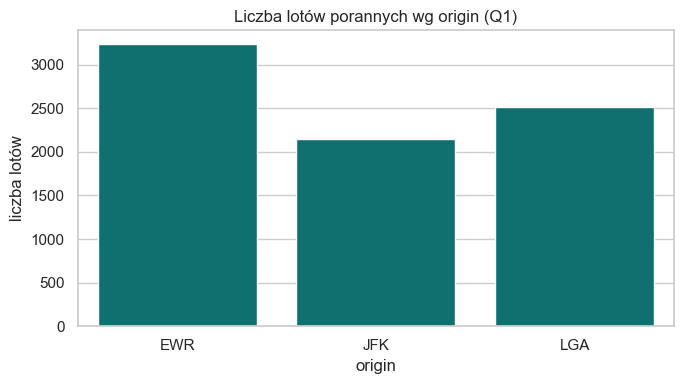

In [2]:
# Tworzymy podzbiór danych do przykładu z porannymi lotami w pierwszym kwartale.
example_count = viz_df.query("month_name in ['Jan', 'Feb', 'Mar'] and dep_hour >= 6 and dep_hour <= 11").copy()

# Tworzymy nową figurę z podanym rozmiarem.
plt.figure(figsize=(7, 4))
# Rysujemy countplot, czyli wykres liczebności kategorii.
sns.countplot(data=example_count, x="origin", order=["EWR", "JFK", "LGA"], color="teal")
# Ustawiamy tytuł wykresu.
plt.title("Liczba lotów porannych wg origin (Q1)")
# Ustawiamy podpis osi X.
plt.xlabel("origin")
# Ustawiamy podpis osi Y.
plt.ylabel("liczba lotów")
# Dopasowujemy układ elementów, aby podpisy i wykresy się nie nachodziły.
plt.tight_layout()
# Wyświetlamy gotową figurę.
plt.show()


## <span style="color:#0f766e; font-weight:700;">Przykład 2: `barplot()` po wcześniejszej agregacji</span>

Najpierw liczymy średni dystans lotu dla każdego przewoźnika, a potem rysujemy wykres słupkowy.

Zwróć uwagę na:
- `errorbar=None` - wyłączenie domyślnych przedziałów błędu,
- poziomy układ słupków przez ustawienie `x` jako miary i `y` jako kategorii.


In [ ]:
# Budujemy tabelę ze średnim dystansem lotu dla każdego przewoźnika.
carrier_distance = viz_df.groupby("carrier_name", as_index=False).agg(distance_mean=("distance", "mean"))
# Budujemy tabelę ze średnim dystansem lotu dla każdego przewoźnika.
carrier_distance = carrier_distance.sort_values("distance_mean", ascending=False).head(8)

# Tworzymy nową figurę z podanym rozmiarem.
plt.figure(figsize=(8, 4))
# Rysujemy barplot dla wcześniej przygotowanej tabeli agregacji.
sns.barplot(data=carrier_distance, x="distance_mean", y="carrier_name", color="steelblue", errorbar=None)
# Ustawiamy tytuł wykresu.
plt.title("Średni dystans lotu wg przewoźnika")
# Ustawiamy podpis osi X.
plt.xlabel("średni dystans [mile]")
# Ustawiamy podpis osi Y.
plt.ylabel("carrier_name")
# Dopasowujemy układ elementów, aby podpisy i wykresy się nie nachodziły.
plt.tight_layout()
# Wyświetlamy gotową figurę.
plt.show()


## <span style="color:#0f766e; font-weight:700;">Przykład 3: `histplot()` z `bins` i `kde`</span>

Badamy rozkład czasu lotu (`air_time`) dla lotów z EWR.

Zwróć uwagę na:
- `bins=30` - liczba koszy histogramu,
- `kde=True` - dodatkowa krzywa gęstości.


In [ ]:
# Tworzymy podzbiór danych do histogramu dla lotów z EWR.
example_hist = viz_df.query("origin == 'EWR' and air_time <= 250").copy()

# Tworzymy nową figurę z podanym rozmiarem.
plt.figure(figsize=(8, 4))
# Rysujemy histogram, aby zobaczyć rozkład wskazanej zmiennej.
sns.histplot(data=example_hist, x="air_time", bins=30, kde=True, color="coral")
# Ustawiamy tytuł wykresu.
plt.title("Rozkład air_time dla lotów z EWR")
# Ustawiamy podpis osi X.
plt.xlabel("air_time [min]")
# Ustawiamy podpis osi Y.
plt.ylabel("liczebność")
# Dopasowujemy układ elementów, aby podpisy i wykresy się nie nachodziły.
plt.tight_layout()
# Wyświetlamy gotową figurę.
plt.show()


## <span style="color:#0f766e; font-weight:700;">Przykład 4: `boxplot()` i `violinplot()` obok siebie</span>

Dwa wykresy pokazują ten sam problem, ale z innej perspektywy:
- `boxplot()` podkreśla medianę, kwartyle i wartości odstające,
- `violinplot()` pokazuje kształt całego rozkładu.


In [ ]:
# Tworzymy podzbiór danych do porównania opóźnień dla wybranych destynacji.
example_box = viz_df.query("dest in ['LAX', 'SFO', 'MIA']").copy()

# Tworzymy dashboard i zapisujemy osobno figurę oraz tablicę osi.
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 4), sharey=True)
# Rysujemy boxplot, aby porównać medianę, kwartyle i wartości odstające.
sns.boxplot(data=example_box, x="dest", y="dep_delay", ax=axes[0], color="lightblue")
# Rysujemy violinplot, aby zobaczyć pełniejszy kształt rozkładu.
sns.violinplot(data=example_box, x="dest", y="dep_delay", ax=axes[1], inner="quartile", color="lightgreen")

# Ustawiamy tytuł konkretnego panelu dashboardu.
axes[0].set_title("Boxplot dep_delay wg dest")
# Ustawiamy podpis osi X dla konkretnego panelu.
axes[0].set_xlabel("dest")
# Ustawiamy podpis osi Y dla konkretnego panelu.
axes[0].set_ylabel("dep_delay [min]")

# Ustawiamy tytuł konkretnego panelu dashboardu.
axes[1].set_title("Violinplot dep_delay wg dest")
# Ustawiamy podpis osi X dla konkretnego panelu.
axes[1].set_xlabel("dest")
# Ustawiamy podpis osi Y dla konkretnego panelu.
axes[1].set_ylabel("dep_delay [min]")

# Dopasowujemy układ elementów, aby podpisy i wykresy się nie nachodziły.
plt.tight_layout()
# Wyświetlamy gotową figurę.
plt.show()


## <span style="color:#0f766e; font-weight:700;">Przykład 5: `scatterplot()` dla relacji distance vs air_time</span>

Pokazujemy zależność między dystansem a czasem lotu na próbce danych.

Zwróć uwagę na:
- `hue=` - kolor rozróżnia lotnisko origin,
- `alpha=` - przezroczystość punktów poprawia czytelność przy dużej liczbie obserwacji,
- `sample(..., random_state=42)` - powtarzalna próba do wykresu.


In [ ]:
# Przygotowujemy źródło danych do przykładu scatterplota.
scatter_source = viz_df.query("distance >= 300").copy()
# Losujemy kontrolowaną próbę obserwacji do wykresu punktowego.
scatter_sample = scatter_source.sample(min(2500, len(scatter_source)), random_state=42)

# Tworzymy nową figurę z podanym rozmiarem.
plt.figure(figsize=(8, 5))
# Rysujemy wykres rozrzutu dla dwóch zmiennych liczbowych.
sns.scatterplot(data=scatter_sample, x="distance", y="air_time", hue="origin", alpha=0.35)
# Ustawiamy tytuł wykresu.
plt.title("distance vs air_time")
# Ustawiamy podpis osi X.
plt.xlabel("distance [mile]")
# Ustawiamy podpis osi Y.
plt.ylabel("air_time [min]")
# Dopasowujemy układ elementów, aby podpisy i wykresy się nie nachodziły.
plt.tight_layout()
# Wyświetlamy gotową figurę.
plt.show()


## <span style="color:#0f766e; font-weight:700;">Przykład 6: `lineplot()` dla trendu miesięcznego</span>

Agregujemy dane do poziomu miesiąc-lotnisko, a następnie rysujemy trend średniego `air_time`.

Zwróć uwagę na:
- `marker='o'` - punkty na linii,
- `hue=` - osobna linia dla każdej kategorii.


In [ ]:
# Agregujemy dane do poziomu miesiąc-lotnisko dla średniego czasu lotu.
monthly_airtime = viz_df.groupby(["month_name", "origin"], as_index=False).agg(air_time_mean=("air_time", "mean"))

# Tworzymy nową figurę z podanym rozmiarem.
plt.figure(figsize=(9, 4))
# Rysujemy wykres liniowy pokazujący trend w czasie lub po uporządkowanej osi.
sns.lineplot(data=monthly_airtime, x="month_name", y="air_time_mean", hue="origin", marker="o")
# Ustawiamy tytuł wykresu.
plt.title("Średni air_time wg miesiąca i origin")
# Ustawiamy podpis osi X.
plt.xlabel("month_name")
# Ustawiamy podpis osi Y.
plt.ylabel("średni air_time [min]")
# Dopasowujemy układ elementów, aby podpisy i wykresy się nie nachodziły.
plt.tight_layout()
# Wyświetlamy gotową figurę.
plt.show()


## <span style="color:#0f766e; font-weight:700;">Przykład 7: `heatmap()` po `pivot_table()`</span>

Najpierw budujemy tabelę przestawną, a potem zamieniamy ją na mapę cieplną.

Zwróć uwagę na:
- `annot=True` - liczby wewnątrz komórek,
- `fmt='.1f'` - format liczb,
- `cmap=` - paleta kolorów,
- `linewidths=0.5` - linie między komórkami.


In [ ]:
# Budujemy tabelę przestawną do heatmapy z opóźnieniem według weekday i origin.
weekday_origin_delay = viz_df.pivot_table(index="weekday", columns="origin", values="dep_delay", aggfunc="mean")

# Tworzymy nową figurę z podanym rozmiarem.
plt.figure(figsize=(6, 4))
# Rysujemy heatmapę dla przygotowanej tabeli przestawnej.
sns.heatmap(weekday_origin_delay, annot=True, fmt=".1f", cmap="YlGnBu", linewidths=0.5)
# Ustawiamy tytuł wykresu.
plt.title("Średni dep_delay wg weekday i origin")
# Ustawiamy podpis osi X.
plt.xlabel("origin")
# Ustawiamy podpis osi Y.
plt.ylabel("weekday")
# Dopasowujemy układ elementów, aby podpisy i wykresy się nie nachodziły.
plt.tight_layout()
# Wyświetlamy gotową figurę.
plt.show()


## <span style="color:#0f766e; font-weight:700;">Przykład 8: `pairplot()` jako wykres bardziej zaawansowany</span>

`pairplot()` pozwala szybko obejrzeć wiele relacji naraz.

Zwróć uwagę na:
- `vars=[...]` - lista zmiennych liczbowych,
- `hue=` - rozróżnienie kategorii kolorem,
- `corner=True` - pokazujemy tylko dolny trójkąt macierzy wykresów.


In [ ]:
# Przygotowujemy próbę danych do przykładowego pairplota.
pair_source = viz_df[["dep_delay", "arr_delay", "air_time", "distance", "origin"]].dropna().sample(400, random_state=42)

# Tworzymy pairplot i zapisujemy obiekt figury do zmiennej `pair_grid`.
pair_grid = sns.pairplot(data=pair_source, vars=["dep_delay", "arr_delay", "air_time", "distance"], hue="origin", corner=True)
# Dodajemy wspólny tytuł nad całym pairplotem.
pair_grid.fig.suptitle("Pairplot dla wybranych zmiennych lotów", y=1.02)
# Zostawiamy trochę miejsca nad pairplotem, aby tytuł się zmieścił.
pair_grid.fig.subplots_adjust(top=0.95)
# Wyświetlamy gotową figurę.
plt.show()


## <span style="color:#0f766e; font-weight:700;">Przykład 9: Dashboard na `plt.subplots()`</span>

Łączymy dwa wykresy w jednym układzie, korzystając z `plt.subplots()`.

Zwróć uwagę na:
- `nrows=1`, `ncols=2` - układ paneli,
- `figsize=(14, 4)` - rozmiar całej figury,
- `ax=...` - wskazanie konkretnego panelu,
- `legend(title='origin')` - własny tytuł legendy.


In [ ]:
# Przygotowujemy dane do przykładowego dashboardu dla trzech przewoźników.
dashboard_df = viz_df.query("carrier in ['AA', 'DL', 'UA']").copy()
# Agregujemy średni dep_delay do panelu liniowego w dashboardzie.
dashboard_line = dashboard_df.groupby(["month_name", "origin"], as_index=False).agg(dep_delay_mean=("dep_delay", "mean"))

# Tworzymy dashboard i zapisujemy osobno figurę oraz tablicę osi.
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 4), sharey=False)
# Rysujemy countplot, czyli wykres liczebności kategorii.
sns.countplot(data=dashboard_df, x="origin", order=["EWR", "JFK", "LGA"], color="slateblue", ax=axes[0])
# Rysujemy wykres liniowy pokazujący trend w czasie lub po uporządkowanej osi.
sns.lineplot(data=dashboard_line, x="month_name", y="dep_delay_mean", hue="origin", marker="o", ax=axes[1])

# Ustawiamy tytuł konkretnego panelu dashboardu.
axes[0].set_title("Liczba lotów AA/DL/UA wg origin")
# Ustawiamy podpis osi X dla konkretnego panelu.
axes[0].set_xlabel("origin")
# Ustawiamy podpis osi Y dla konkretnego panelu.
axes[0].set_ylabel("liczba lotów")

# Ustawiamy tytuł konkretnego panelu dashboardu.
axes[1].set_title("Średni dep_delay wg miesiąca i origin")
# Ustawiamy podpis osi X dla konkretnego panelu.
axes[1].set_xlabel("month_name")
# Ustawiamy podpis osi Y dla konkretnego panelu.
axes[1].set_ylabel("średni dep_delay [min]")
# Ustawiamy legendę w konkretnym panelu i nadajemy jej tytuł.
axes[1].legend(title="origin")

# Dopasowujemy układ elementów, aby podpisy i wykresy się nie nachodziły.
plt.tight_layout()
# Wyświetlamy gotową figurę.
plt.show()


# <span style="color:#0f766e; font-weight:700;">15. Zadania obowiązkowe (1-15)</span>

Zadania obowiązkowe prowadzą od prostych wykresów kategorycznych i rozkładów
do heatmap, pairplotów i dashboardów.


## <span style="color:#0f766e; font-weight:700;">Zadanie 1</span>

Porównaj najczęstszych przewoźników na lotniskach `JFK` i `LGA` w miesiącach `Apr`, `May`, `Jun`.

Pracuj tak:
1. utwórz `task1_df` tylko dla tych lotnisk i miesięcy,
2. zbuduj `carrier_order` jako listę 8 najczęstszych wartości `carrier_name`,
3. użyj `carrier_order` w parametrze `order=...`,
4. narysuj `countplot()` dla `carrier_name`,
5. obróć etykiety osi X o 45 stopni.

Na wykresie ustaw:
- `figsize=(10, 4)`,
- `color='darkcyan'`.

Wymagane funkcje/parametry:
- `query()`
- `value_counts()`
- `head(8)`
- `sns.countplot(data=..., x=..., order=..., color=...)`
- `plt.xticks(rotation=45)`
- `plt.tight_layout()`

Kryterium zaliczenia:
- wykres pokazuje 8 najczęstszych przewoźników,
- kolejność słupków wynika z danych,
- podpisy są czytelne.

Checkpoint:
- pokaż prowadzącemu gotowy wykres.


Index(['United Air Lines Inc.', 'JetBlue Airways', 'ExpressJet Airlines Inc.',
       'Delta Air Lines Inc.', 'American Airlines Inc.', 'Envoy Air',
       'US Airways Inc.', 'Endeavor Air Inc.'],
      dtype='str', name='carrier_name')


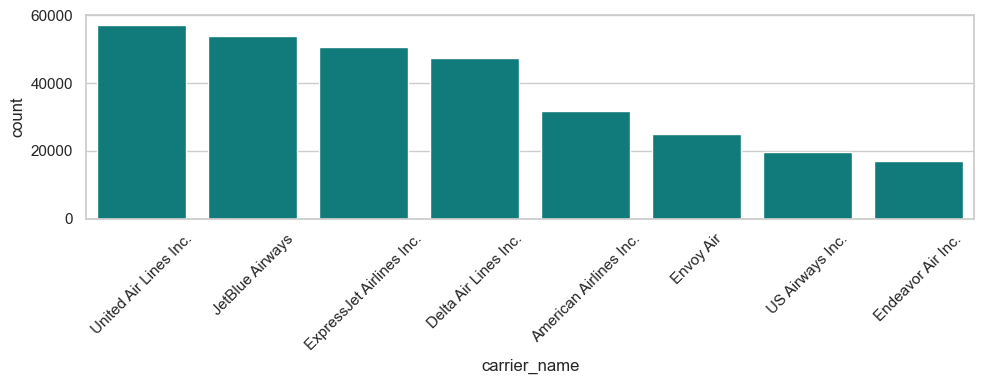

In [22]:
# tutaj dodaj swój kod
task1_df = viz_df.query("origin in ['JFK', 'LGA'] and month_name in ['Apr','May','Jun']")
carrier_order = viz_df['carrier_name'].value_counts(ascending=False).head(8).index
print(carrier_order)

plt.figure(figsize=(10,4))
sns.countplot(data=viz_df, x="carrier_name", order=carrier_order, color="darkcyan")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



## <span style="color:#0f766e; font-weight:700;">Zadanie 2</span>

Pokaż TOP 10 destynacji dla lotów dalekiego zasięgu (`distance >= 1500`).

Pracuj tak:
1. utwórz `task2_df`,
2. zbuduj tabelę `dest_counts` z kolumnami `dest` i `flights_n`,
3. posortuj wynik malejąco po `flights_n`,
4. zostaw 10 pierwszych destynacji,
5. narysuj `barplot()` z `x='dest'` i `y='flights_n'`.

Na wykresie ustaw:
- `figsize=(10, 4)`,
- `color='indianred'`,
- `errorbar=None`,
- obrót etykiet osi X o 45 stopni.

Wymagane funkcje/parametry:
- `query()`
- `groupby(...).agg(...)`
- `sort_values(..., ascending=False)`
- `head(10)`
- `sns.barplot(data=..., x=..., y=..., color=..., errorbar=None)`

Kryterium zaliczenia:
- wykres pokazuje dokładnie 10 destynacji,
- słupki są posortowane malejąco,
- oś Y pokazuje liczbę lotów.


      flights_n
dest           
LAX       15969
SFO       13085
DEN        7112
LAS        5929
SJU        5767
PHX        4582
SEA        3869
SAN        2699
SLC        2439
AUS        2400


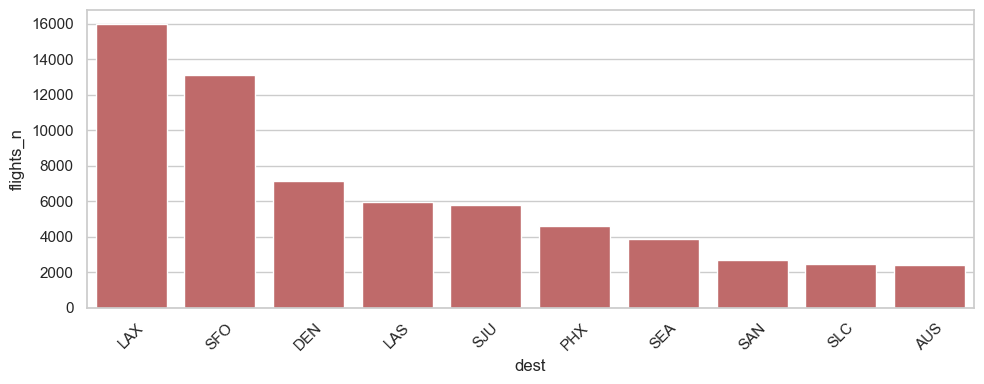

In [23]:
# tutaj dodaj swój kod
task2_df =  viz_df.query("distance >=1500")
dest_counts = task2_df.groupby(by='dest').agg(
    
    flights_n = ('distance', 'count'))

dest_counts = dest_counts.sort_values('flights_n',ascending=False).head(10)
print(dest_counts)

plt.figure(figsize=(10,4))
sns.barplot(data=dest_counts, x="dest", y="flights_n", color="indianred", errorbar=None)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## <span style="color:#0f766e; font-weight:700;">Zadanie 3</span>

Zobacz rozkład `arr_delay` dla lotów do `ORD`, `ATL`, `MIA`.

Pracuj tak:
1. utwórz `task3_df` tylko dla `dest` z listy `['ORD', 'ATL', 'MIA']`,
2. w tym samym filtrowaniu zostaw tylko obserwacje z `arr_delay` od `-60` do `180`,
3. narysuj histogram z krzywą KDE.

Na wykresie ustaw:
- `bins=35`,
- `kde=True`,
- `color='goldenrod'`,
- `figsize=(8, 4)`.

Wymagane funkcje/parametry:
- `query()`
- `sns.histplot(data=..., x=..., bins=..., kde=..., color=...)`

Kryterium zaliczenia:
- histogram pokazuje tylko wskazane destynacje,
- oś X odpowiada `arr_delay`,
- na wykresie nie ma skrajnych opóźnień spoza wskazanego zakresu.


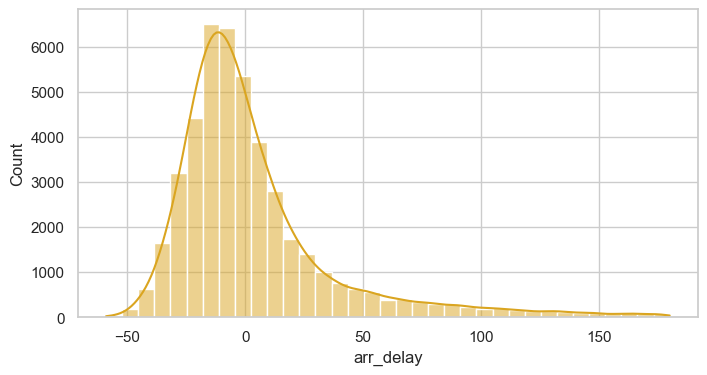

In [27]:
task3_df =  viz_df.query("dest in ['ORD','ATL','MIA'] and -60 <= arr_delay <= 180")

plt.figure(figsize=(8, 4))
sns.histplot(data=task3_df, x="arr_delay", bins=35, kde=True, color="goldenrod")
plt.show()



## <span style="color:#0f766e; font-weight:700;">Zadanie 4</span>

Porównaj `air_time` między lotniskami origin dla przewoźników `AA`, `DL`, `UA`.

Pracuj tak:
1. utwórz `task4_df` tylko dla przewoźników `AA`, `DL`, `UA`,
2. narysuj `boxplot()` z `x='origin'` i `y='air_time'`.

Na wykresie ustaw:
- `figsize=(8, 4)`,
- `color='lightskyblue'`.

Wymagane funkcje/parametry:
- `query()`
- `sns.boxplot(data=..., x=..., y=..., color=...)`

Kryterium zaliczenia:
- wykres pokazuje porównanie `EWR`, `JFK`, `LGA`,
- oś Y przedstawia `air_time`.


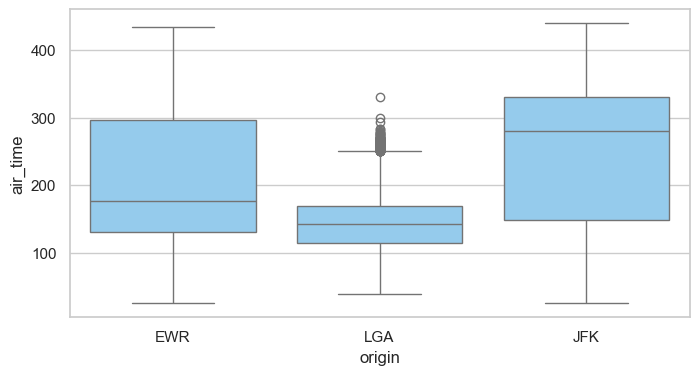

In [29]:
task4_df =  viz_df.query("carrier in ['AA','DL','UA']")

plt.figure(figsize=(8,4))
sns.boxplot(data=task4_df, x="origin", y="air_time", color="lightskyblue")
plt.show()


## <span style="color:#0f766e; font-weight:700;">Zadanie 5</span>

Pokaż rozkład `distance` dla lotów na Florydę (`MCO`, `FLL`, `TPA`) w podziale na `origin`.

Pracuj tak:
1. utwórz `task5_df` tylko dla `dest` z listy `['MCO', 'FLL', 'TPA']`,
2. narysuj `violinplot()`,
3. na osi X pokaż `origin`, a na osi Y `distance`.

Na wykresie ustaw:
- `x='origin'`,
- `y='distance'`,
- `inner='quartile'`,
- `color='mediumseagreen'`.

Wymagane funkcje/parametry:
- `query()`
- `sns.violinplot(data=..., x=..., y=..., inner='quartile', color=...)`

Kryterium zaliczenia:
- wykres używa violinplota,
- w środku są widoczne kwartyle,
- każda grupa na osi X odpowiada lotnisku origin.


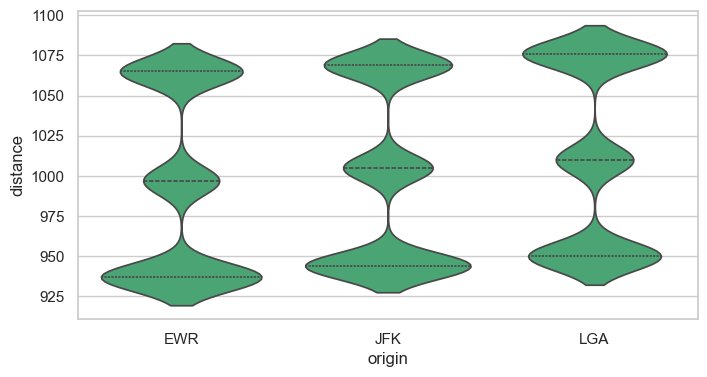

In [31]:
task5_df =  viz_df.query("dest in ['MCO','FLL','TPA']")

plt.figure(figsize=(8, 4))
sns.violinplot(data=task5_df, x="origin", y="distance", inner="quartile", color="mediumseagreen")
plt.show()





## <span style="color:#0f766e; font-weight:700;">Zadanie 6</span>

Sprawdź relację między temperaturą a opóźnieniem odlotu.

Pracuj tak:
1. z `viz_df` wybierz tylko rekordy bez braków w `temp`, `dep_delay`, `origin`,
2. zapisz wynik jako `task6_source`,
3. wylosuj próbę do `task6_sample` o liczebności `min(2000, len(task6_source))`,
4. narysuj `scatterplot()` dla tej próby.

Na wykresie ustaw:
- `x='temp'`,
- `y='dep_delay'`,
- `hue='origin'`,
- `alpha=0.35`,
- `figsize=(8, 5)`.

Wymagane funkcje/parametry:
- `dropna(subset=[...])`
- `sample(..., random_state=42)`
- `sns.scatterplot(data=..., x=..., y=..., hue=..., alpha=...)`

Kryterium zaliczenia:
- wykres używa próby danych,
- kolory odróżniają lotnisko origin.


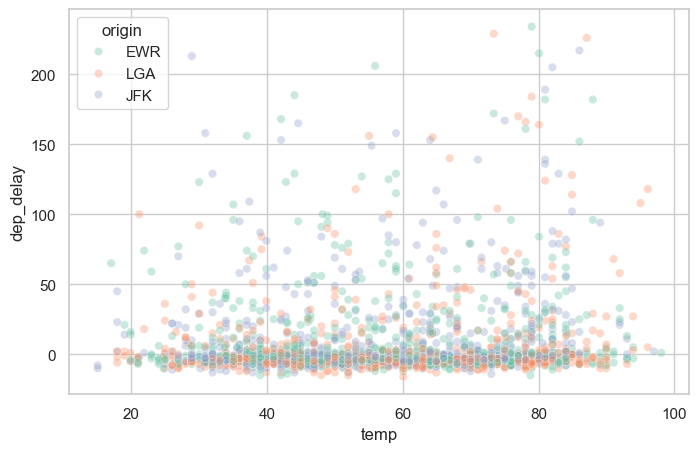

In [34]:
task6_source = viz_df.dropna(subset=['temp','dep_delay','origin'])
task6_sample = task6_source.sample(min(2000,len(task6_source)),random_state=42)

plt.figure(figsize=(8,5))
sns.scatterplot(data=task6_sample, x="temp", y="dep_delay", hue="origin", alpha=0.35)
plt.show()






## <span style="color:#0f766e; font-weight:700;">Zadanie 7</span>

Pokaż `on_time_rate` w kolejnych miesiącach dla `AA`, `DL`, `UA`.

Pracuj tak:
1. utwórz `task7_df` tylko dla przewoźników `AA`, `DL`, `UA`,
2. zbuduj tabelę `task7_line` z grupowaniem po `month_name` i `carrier_name`,
3. policz średnią z `on_time_flag` i zapisz ją jako kolumnę `on_time_rate`,
4. narysuj `lineplot()`.

Na wykresie ustaw:
- `hue='carrier_name'`,
- `marker='o'`,
- `figsize=(9, 4)`.

Wymagane funkcje/parametry:
- `query()`
- `groupby(...).agg(...)`
- `sns.lineplot(data=..., x=..., y=..., hue=..., marker='o')`

Kryterium zaliczenia:
- wykres pokazuje trzy linie,
- oś Y przedstawia `on_time_rate`.


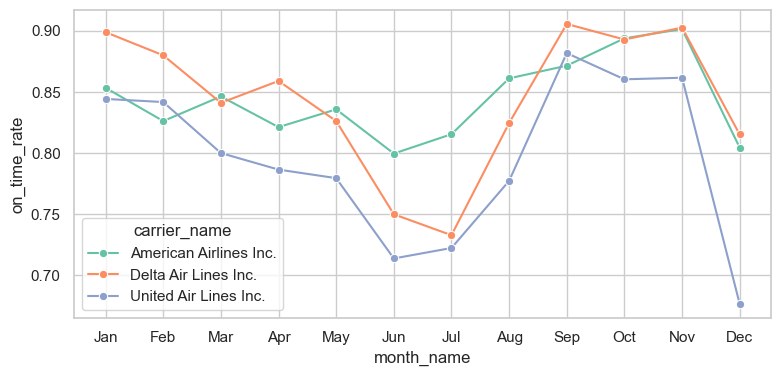

In [41]:
task7_df = viz_df.query("carrier in ['AA','DL','UA']")
task7_line = task7_df.groupby(by=['month_name','carrier_name']).agg(
    on_time_rate=('on_time_flag','mean')
).reset_index()

plt.figure(figsize=(9, 4))
sns.lineplot(data=task7_line, x="month_name", y="on_time_rate", hue="carrier_name", marker="o")
plt.show()



## <span style="color:#0f766e; font-weight:700;">Zadanie 8</span>

Porównaj średni `arr_delay` w zależności od godziny odlotu i lotniska origin.

Pracuj tak:
1. utwórz `task8_df` dla godzin `5-22`,
2. zbuduj tabelę `task8_line` z grupowaniem po `dep_hour` i `origin`,
3. policz średnią z `arr_delay` i zapisz ją jako `arr_delay_mean`,
4. narysuj `lineplot()`.

Na wykresie ustaw:
- `x='dep_hour'`,
- `y='arr_delay_mean'`,
- `hue='origin'`,
- `marker='o'`.

Wymagane funkcje/parametry:
- `query()`
- `groupby(...).agg(...)`
- `sns.lineplot(...)`

Kryterium zaliczenia:
- na wykresie widać trzy linie dla origin,
- na osi X są godziny,
- oś Y pokazuje średni `arr_delay`.


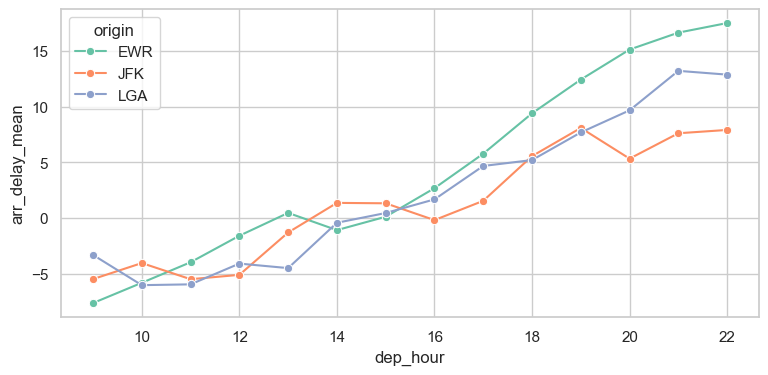

In [44]:
task8_df = viz_df.query("5<= dep_hour <=22")

task8_line = task8_df.groupby(by=['dep_hour','origin']).agg(

    arr_delay_mean = ('arr_delay','mean')

).reset_index()

plt.figure(figsize=(9, 4))
sns.lineplot(data=task8_line, x="dep_hour", y="arr_delay_mean", hue="origin", marker="o")
plt.show()



## <span style="color:#0f766e; font-weight:700;">Zadanie 9</span>

Zbuduj heatmapę średniego `arr_delay` w układzie `weekday x dep_hour`.

Pracuj tak:
1. utwórz `task9_df` dla godzin `5-22`,
2. zbuduj `task9_heatmap` przez `pivot_table(index='weekday', columns='dep_hour', values='arr_delay', aggfunc='mean')`,
3. narysuj `heatmap()`.

Na wykresie ustaw:
- `annot=True`,
- `fmt='.1f'`,
- `cmap='YlOrRd'`,
- `linewidths=0.5`,
- `figsize=(12, 4)`.

Wymagane funkcje/parametry:
- `pivot_table(index=..., columns=..., values=..., aggfunc='mean')`
- `sns.heatmap(...)`

Kryterium zaliczenia:
- wiersze to `weekday`,
- kolumny to `dep_hour`,
- komórki mają opis liczbowy.


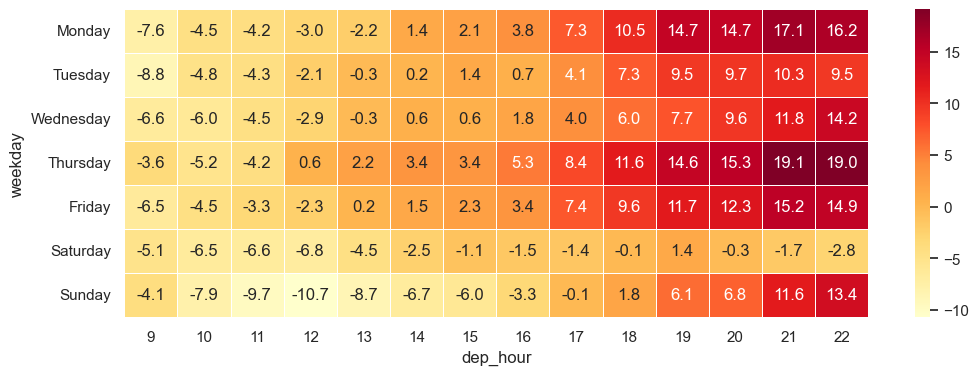

In [46]:
task9_df = viz_df.query("5<= dep_hour <=22")
task9_heatmap = task9_df.pivot_table(index="weekday", columns="dep_hour", values="arr_delay", aggfunc="mean")

plt.figure(figsize=(12, 4))
sns.heatmap(task9_heatmap, annot=True, fmt=".1f", cmap="YlOrRd", linewidths=0.5)
plt.show()

## <span style="color:#0f766e; font-weight:700;">Zadanie 10</span>

Zbuduj heatmapę średniej temperatury w układzie `month_name x origin`.

Pracuj tak:
1. usuń braki w `temp`,
2. zapisz dane jako `task10_df`,
3. zbuduj `task10_heatmap` przez `pivot_table(index='month_name', columns='origin', values='temp', aggfunc='mean')`,
4. narysuj `heatmap()`.

Na wykresie ustaw:
- `annot=True`,
- `fmt='.1f'`,
- `cmap='coolwarm'`,
- `linewidths=0.5`,
- `figsize=(6, 4)`.

Wymagane funkcje/parametry:
- `dropna(subset=[...])`
- `pivot_table(index=..., columns=..., values=..., aggfunc='mean')`
- `sns.heatmap(data=..., annot=..., fmt=..., cmap=..., linewidths=...)`

Kryterium zaliczenia:
- heatmapa pokazuje temperaturę, a nie opóźnienia,
- miesiące są na osi Y.


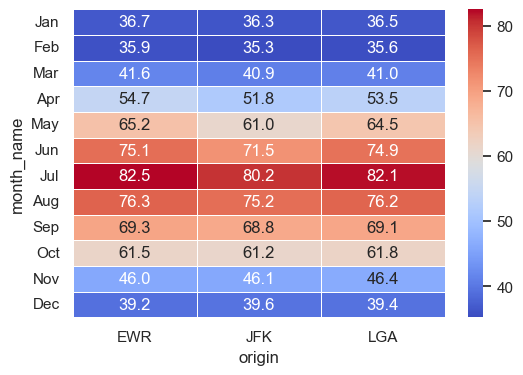

In [48]:
task10_df = viz_df.dropna(subset=['temp'])
task10_heatmap = task10_df.pivot_table(index="month_name", columns="origin", values="temp", aggfunc="mean")

plt.figure(figsize=(6, 4))
sns.heatmap(task10_heatmap, annot=True, fmt=".1f", cmap="coolwarm", linewidths=0.5)
plt.show()



## <span style="color:#0f766e; font-weight:700;">Zadanie 11</span>

Zbuduj bardziej zaawansowany wykres `pairplot()` dla lotów.

Pracuj tak:
1. z `viz_df` wybierz dokładnie kolumny `dep_delay`, `arr_delay`, `air_time`, `distance`, `origin`,
2. usuń w tych kolumnach braki i wylosuj próbę 350 wierszy z `random_state=42`,
3. zapisz wynik jako `task11_pair`,
4. zbuduj `pairplot()` dla zmiennych `dep_delay`, `arr_delay`, `air_time`, `distance`,
5. ustaw `hue='origin'`,
6. ustaw `corner=True`.

Dodatkowo:
- dodaj tytuł `Pairplot dla lotów według origin` przez `fig.suptitle(..., y=1.02)`,
- popraw układ przez `fig.subplots_adjust(top=0.95)`.

Wymagane funkcje/parametry:
- `dropna()`
- `sample(350, random_state=42)`
- `sns.pairplot(data=..., vars=[...], hue=..., corner=True)`
- `fig.suptitle(..., y=...)`
- `fig.subplots_adjust(top=...)`

Kryterium zaliczenia:
- wykres pokazuje tylko dolny trójkąt,
- kolor rozróżnia origin.


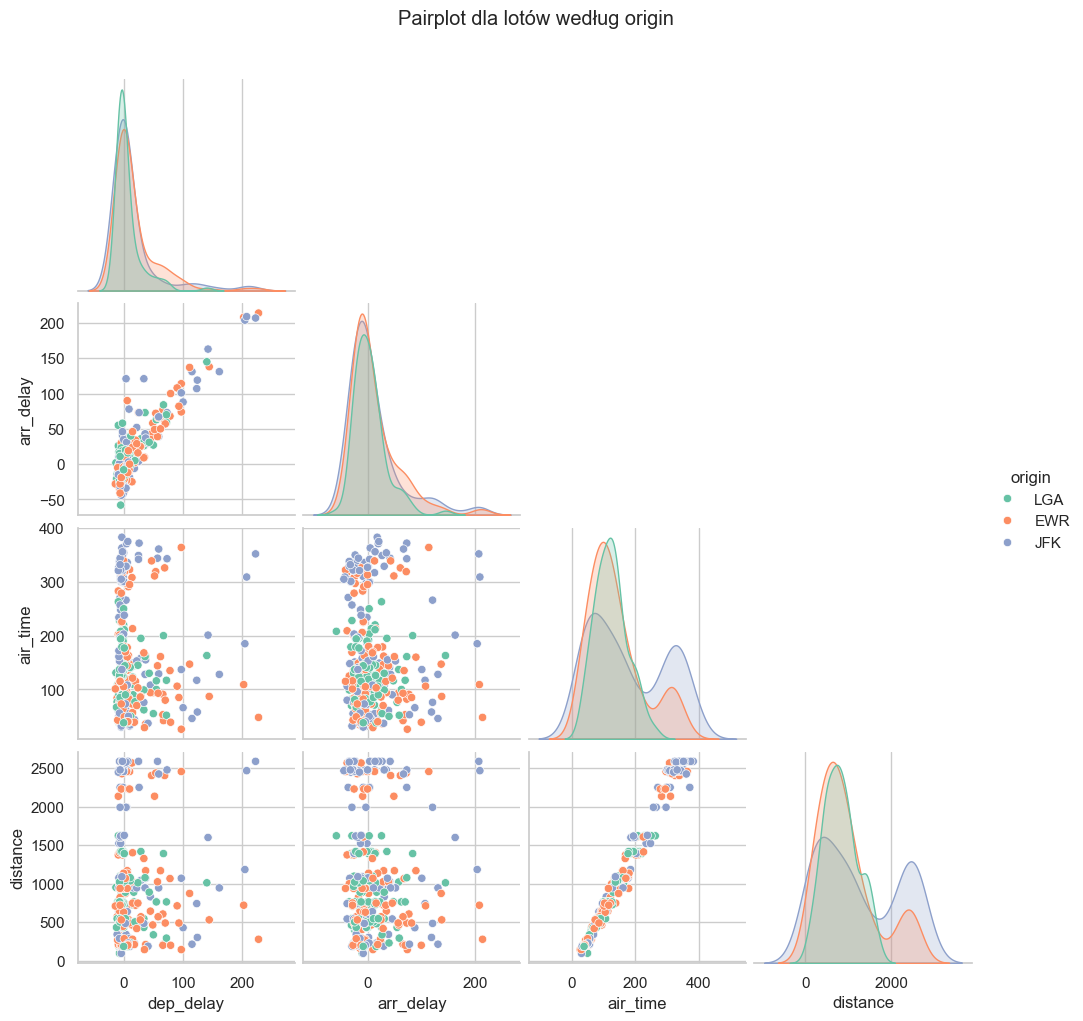

In [50]:
task11_pair = viz_df[['dep_delay','arr_delay','air_time','distance','origin']].dropna().sample(350,random_state=42)
paraplot = sns.pairplot(data=task11_pair, vars=["dep_delay", "arr_delay", "air_time", "distance"], hue="origin", corner=True)
paraplot.fig.suptitle("Pairplot dla lotów według origin",y=1.02)
paraplot.fig.subplots_adjust(top=0.95)

## <span style="color:#0f766e; font-weight:700;">Zadanie 12</span>

Przygotuj dashboard 1x2.

Panel lewy:
- histogram `distance` dla lotów z `JFK`,
- `bins=30`,
- `kde=True`,
- `color='navy'`.

Panel prawy:
- boxplot `dep_delay` wg `origin`,
- tylko dla lotów do `LAX`, `SFO`, `SEA`,
- `color='thistle'`.

Pracuj tak:
1. przygotuj `task12_left` tylko dla lotów z `JFK`,
2. przygotuj `task12_right` tylko dla lotów do `LAX`, `SFO`, `SEA`,
3. utwórz `plt.subplots(nrows=1, ncols=2, figsize=(14, 4), sharey=False)`,
4. narysuj oba wykresy do odpowiednich osi przez `ax=...`.

Wymagane funkcje/parametry:
- `query()`
- `plt.subplots(nrows=..., ncols=..., figsize=..., sharey=False)`
- `sns.histplot(data=..., x=..., bins=..., kde=..., color=..., ax=...)`
- `sns.boxplot(data=..., x=..., y=..., color=..., ax=...)`
- `axes[...].set_title(...)`
- `axes[...].set_xlabel(...)`
- `axes[...].set_ylabel(...)`

Kryterium zaliczenia:
- oba wykresy są w jednej figurze,
- każdy panel ma własny tytuł i podpisy osi.


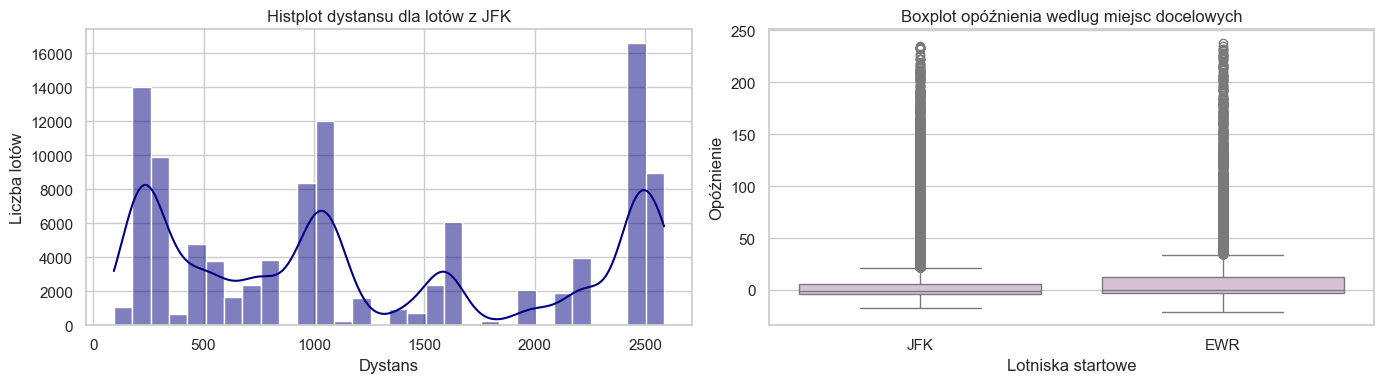

In [52]:
task12_left = viz_df.query("origin in ['JFK']")
task12_right = viz_df.query("dest in ['LAX','SFO','SEA']")

fig, axes = plt.subplots(nrows=1,ncols=2,figsize=(14,4),sharey=False)
sns.histplot(data=task12_left, x="distance", bins=30, kde=True,color='navy', ax=axes[0])
sns.boxplot(data=task12_right, x='origin',y='dep_delay',color='thistle',ax=axes[1] )

axes[0].set_title("Histplot dystansu dla lotów z JFK")
axes[0].set_xlabel("Dystans")
axes[0].set_ylabel("Liczba lotów")

axes[1].set_title("Boxplot opóźnienia wedlug miejsc docelowych")
axes[1].set_xlabel("Lotniska startowe")
axes[1].set_ylabel("Opóźnienie")

plt.tight_layout()
plt.show()

## <span style="color:#0f766e; font-weight:700;">Zadanie 13</span>

Przygotuj dashboard 2x2 z czterema różnymi wizualizacjami.

Panel 1:
- `countplot()` liczby lotów `B6` wg `month_name`,
- użyj `order=month_order`,
- ustaw `color='slateblue'`.

Panel 2:
- `barplot()` TOP 6 dest dla `AA` wg średniego `air_time`,
- najpierw zbuduj `task13_dest` i zostaw 6 rekordów z najwyższym `air_time_mean`,
- ustaw `color='darkorange'` i `errorbar=None`.

Panel 3:
- `lineplot()` średniej `temp` wg `month_name` i `origin`,
- użyj `marker='o'`.

Panel 4:
- `heatmap()` średniego `dep_delay` w układzie `month_name x origin`,
- użyj `annot=True`, `fmt='.1f'`, `cmap='YlGnBu'`, `linewidths=0.5`.

Pracuj tak:
1. przygotuj osobne tabele `task13_b6`, `task13_dest`, `task13_temp`, `task13_heatmap`,
2. zbuduj układ `plt.subplots(nrows=2, ncols=2, figsize=(14, 9), sharey=False)`,
3. dopisz osobne tytuły i podpisy osi,
4. obróć etykiety osi X tam, gdzie nazwy są dłuższe,
5. dodaj legendę z `title='origin'` na wykresie liniowym.

Wymagane funkcje/parametry:
- `query()`
- `groupby(..., as_index=False).agg(...)`
- `sort_values(..., ascending=False)`
- `head(6)`
- `pivot_table(index=..., columns=..., values=..., aggfunc='mean')`
- `plt.subplots(...)`
- `ax=...`
- `tick_params(axis='x', rotation=45)`
- `legend(title='origin')`

Kryterium zaliczenia:
- wszystkie 4 wykresy są w jednej figurze,
- układ jest czytelny po `tight_layout()`.


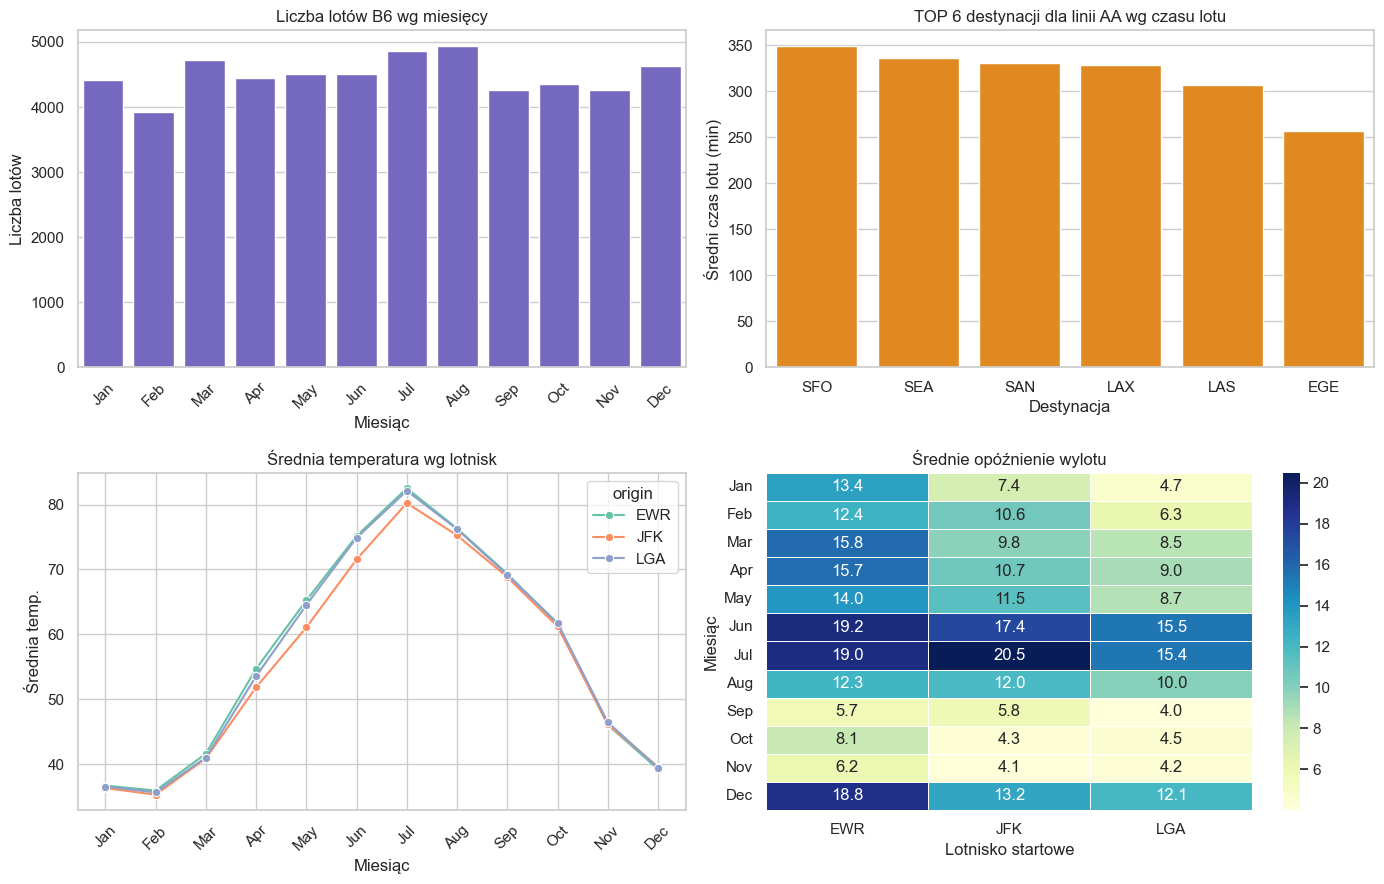

In [ ]:
task13_b6 = viz_df.query("carrier == 'B6'")

task13_dest = viz_df.query("carrier == 'AA'").groupby('dest', as_index=False).agg(
    air_time_mean=('air_time', 'mean')
).sort_values('air_time_mean', ascending=False).head(6)

task13_temp = viz_df.dropna(subset=['temp']).groupby(['month_name', 'origin'], as_index=False).agg(
    temp_mean=('temp', 'mean')
)

task13_heatmap = viz_df.pivot_table(index='month_name', columns='origin', values='dep_delay', aggfunc='mean')

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 9), sharey=False)
sns.countplot(data=task13_b6, x='month_name', order=month_order, color='slateblue', ax=axes[0, 0])
sns.barplot(data=task13_dest, x='dest', y='air_time_mean', color='darkorange', errorbar=None, ax=axes[0, 1])
sns.lineplot(data=task13_temp, x='month_name', y='temp_mean', hue='origin', marker='o', ax=axes[1, 0])
sns.heatmap(task13_heatmap, annot=True, fmt='.1f', cmap='YlGnBu', linewidths=0.5, ax=axes[1, 1])

axes[0, 0].set_title("Liczba lotów B6 wg miesięcy")
axes[0, 0].set_xlabel("Miesiąc")
axes[0, 0].set_ylabel("Liczba lotów")
axes[0, 0].tick_params(axis='x', rotation=45)

axes[0, 1].set_title("TOP 6 destynacji dla linii AA wg czasu lotu")
axes[0, 1].set_xlabel("Destynacja")
axes[0, 1].set_ylabel("Średni czas lotu (min)")

axes[1, 0].set_title("Średnia temperatura wg lotnisk")
axes[1, 0].set_xlabel("Miesiąc")
axes[1, 0].set_ylabel("Średnia temp.")
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].legend(title='origin')

axes[1, 1].set_title("Średnie opóźnienie wylotu")
axes[1, 1].set_xlabel("Lotnisko startowe")
axes[1, 1].set_ylabel("Miesiąc")

plt.tight_layout()
plt.show()

## <span style="color:#0f766e; font-weight:700;">Zadanie 14</span>

Pokaż przewoźników z najwyższą medianą `arr_delay`.

Pracuj tak:
1. zbuduj `task14_delay` z kolumnami:
   - `carrier_name`
   - `flights_n`
   - `arr_delay_median`
2. policz `flights_n` jako liczbę rekordów i `arr_delay_median` jako medianę `arr_delay`,
3. zostaw tylko przewoźników z `flights_n >= 5000`,
4. posortuj malejąco po `arr_delay_median`,
5. zostaw 8 pierwszych,
6. narysuj poziomy `barplot()`.

Na wykresie ustaw:
- `x='arr_delay_median'`,
- `y='carrier_name'`,
- `color='firebrick'`,
- `errorbar=None`,
- `figsize=(9, 4)`.

Wymagane funkcje/parametry:
- `groupby(..., as_index=False).agg(...)`
- `query()`
- `sort_values(..., ascending=False)`
- `head(8)`
- `sns.barplot(data=..., x=..., y=..., color=..., errorbar=None)`

Kryterium zaliczenia:
- wykres pokazuje ranking 8 przewoźników,
- oś X przedstawia medianę `arr_delay`.


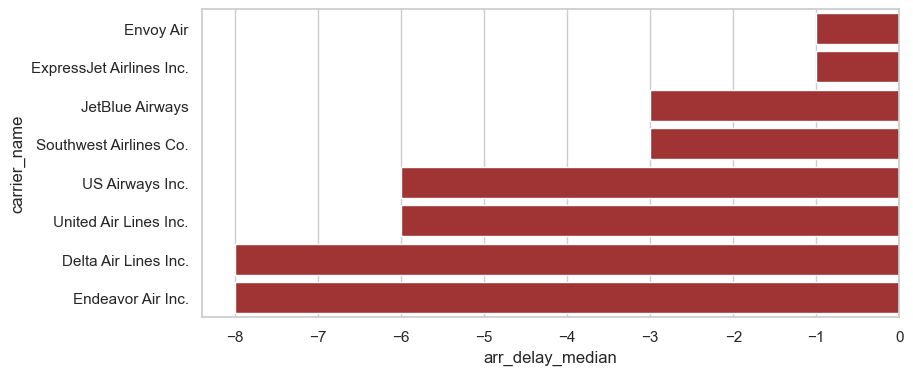

In [55]:
task14_delay = viz_df.groupby('carrier_name', as_index=False).agg(
    flights_n=('carrier_name', 'count'),
    arr_delay_median=('arr_delay', 'median')
)

task14_delay = task14_delay.query("flights_n >= 5000")
task14_delay = task14_delay.sort_values('arr_delay_median', ascending=False).head(8)

plt.figure(figsize=(9, 4))
sns.barplot(data=task14_delay, x='arr_delay_median', y='carrier_name', color='firebrick', errorbar=None)
plt.show()

## <span style="color:#0f766e; font-weight:700;">Zadanie 15</span>

Przygotuj końcowy mini-raport wizualny 1x3.

Panel 1:
- `countplot()` dla `weekday`,
- tylko opóźnione odloty (`is_delayed_dep == 1`) z `JFK`.

Panel 2:
- `lineplot()` średniego `wind_speed` wg `month_name` i `origin`.

Panel 3:
- `barplot()` TOP 6 dest wg średniego `air_time`.

Po wykresach:
- utwórz listę `insights` z 4 krótkimi wnioskami,
- wypisz każdy wniosek w osobnej linii.

Pracuj tak:
1. przygotuj `report_left` tylko dla `origin == 'JFK'` oraz `is_delayed_dep == 1`,
2. przygotuj `report_middle` jako średni `wind_speed` w układzie `month_name x origin`,
3. przygotuj `report_right` jako TOP 6 dest wg średniego `air_time`,
4. zbuduj układ `plt.subplots(nrows=1, ncols=3, figsize=(18, 4), sharey=False)`,
5. narysuj trzy panele w kolejności zgodnej z opisem zadania.

Wymagane elementy:
- `plt.subplots(nrows=1, ncols=3, figsize=(18, 4), sharey=False)`
- `tick_params(axis='x', rotation=45)` tam, gdzie etykiety są długie
- `legend(title='origin')` na wykresie liniowym
- lista `insights` z dokładnie 4 elementami

Wymagane funkcje/parametry:
- `query()`
- `dropna(subset=[...])`
- `groupby(..., as_index=False).agg(...)`
- `sort_values(..., ascending=False)`
- `head(6)`
- `plt.subplots(...)`
- `sns.countplot(..., ax=...)`
- `sns.lineplot(..., ax=...)`
- `sns.barplot(..., ax=...)`

Kryterium zaliczenia:
- raport zawiera 3 wykresy i 4 wnioski tekstowe.


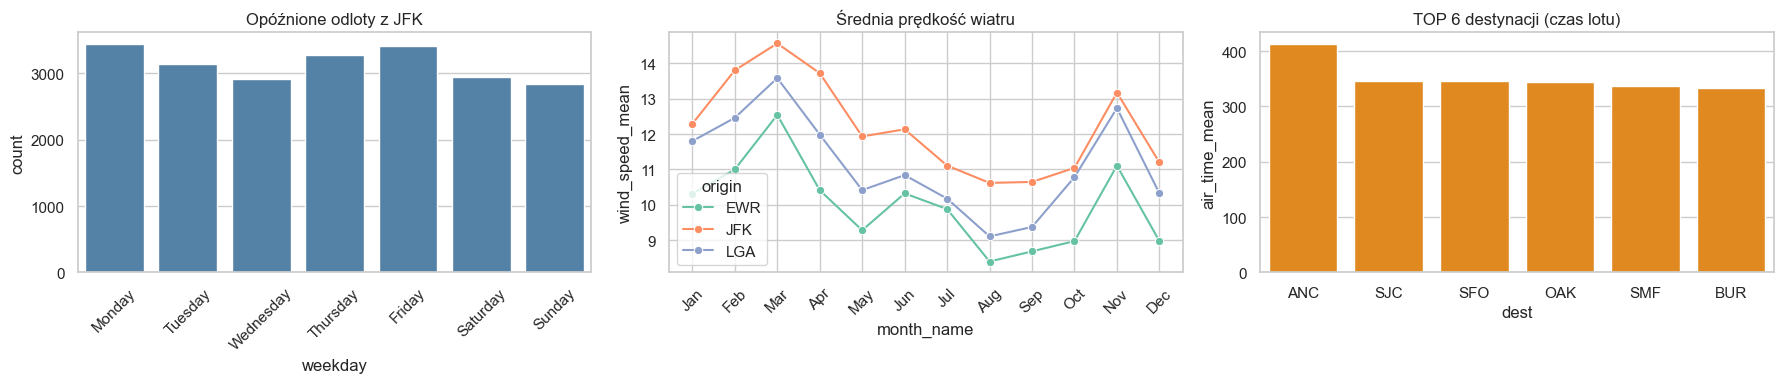

In [56]:
report_left = viz_df.query("origin == 'JFK' and is_delayed_dep == 1")

report_middle = viz_df.dropna(subset=['wind_speed']).groupby(['month_name', 'origin'], as_index=False).agg(
    wind_speed_mean=('wind_speed', 'mean')
)

report_right = viz_df.groupby('dest', as_index=False).agg(
    air_time_mean=('air_time', 'mean')
)

report_right = report_right.sort_values('air_time_mean', ascending=False).head(6)

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 4), sharey=False)

sns.countplot(data=report_left, x='weekday', color='steelblue', ax=axes[0])
sns.lineplot(data=report_middle, x='month_name', y='wind_speed_mean', hue='origin', marker='o', ax=axes[1])
sns.barplot(data=report_right, x='dest', y='air_time_mean', color='darkorange', errorbar=None, ax=axes[2])

axes[0].set_title("Opóźnione odloty z JFK")
axes[0].tick_params(axis='x', rotation=45)


axes[1].set_title("Średnia prędkość wiatru")
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='origin')


axes[2].set_title("TOP 6 destynacji (czas lotu)")

plt.tight_layout()
plt.show()


Wnioski

1. Poniedzialki i piątki to dni z najwyzszą liczbą opóźnionych odlotow z JFK.
2. Śr. pr. wiatru osiąga najwyższe wartości w marcu i kwietniu
3. Lotnisko JFK notuje najwyższą śr. pr. wiatru w porównaniu do pozostalych.
4. Do lotniska ANC na tle 5 innych leci się srednio najdluzej.

# <span style="color:#0f766e; font-weight:700;">16. Zadania dodatkowe (16-23)</span>

Zadania dodatkowe rozszerzają lekcję o kolejne zastosowania tych samych narzędzi.


## <span style="color:#0f766e; font-weight:700;">Zadanie 16 - dodatkowe</span>

Pokaż liczbę lotów przy opadach (`precip > 0`) w kolejnych dniach tygodnia.

Pracuj tak:
1. utwórz `extra16_df`,
2. narysuj `countplot()` dla `weekday`,
3. użyj `order=weekday_order`,
4. obróć etykiety osi X o 45 stopni.

Na wykresie ustaw:
- `figsize=(9, 4)`,
- `color='royalblue'`.


In [ ]:
# tutaj dodaj swój kod


## <span style="color:#0f766e; font-weight:700;">Zadanie 17 - dodatkowe</span>

Zobacz rozkład `wind_speed` tylko dla lotów z opadami.

Pracuj tak:
1. utwórz `extra17_df`,
2. narysuj `histplot()` z `bins=30`, `kde=True`, `color='cadetblue'`.

Na wykresie ustaw:
- `x='wind_speed'`,
- `figsize=(8, 4)`.


In [ ]:
# tutaj dodaj swój kod


## <span style="color:#0f766e; font-weight:700;">Zadanie 18 - dodatkowe</span>

Porównaj rozkład temperatury między lotniskami origin.

Pracuj tak:
1. usuń braki w `temp`,
2. zapisz wynik jako `extra18_df`,
3. narysuj `boxplot()` dla `temp` wg `origin`.

Na wykresie ustaw:
- `color='lightcoral'`,
- `figsize=(8, 4)`.


In [ ]:
# tutaj dodaj swój kod


## <span style="color:#0f766e; font-weight:700;">Zadanie 19 - dodatkowe</span>

Pokaż rozkład `arr_delay` dla 5 najczęstszych przewoźników.

Pracuj tak:
1. wyznacz `extra19_order` jako 5 najczęstszych `carrier_name`,
2. utwórz `extra19_df` tylko dla tych 5 przewoźników,
3. narysuj `violinplot()` z `inner='quartile'`.

Na wykresie ustaw:
- `x='carrier_name'`,
- `y='arr_delay'`,
- `color='orchid'`,
- `figsize=(10, 4)`.


In [ ]:
# tutaj dodaj swój kod


## <span style="color:#0f766e; font-weight:700;">Zadanie 20 - dodatkowe</span>

Zobacz relację `wind_speed` vs `arr_delay` na próbie danych.

Pracuj tak:
1. przygotuj `extra20_source`,
2. wylosuj `extra20_sample`,
3. narysuj `scatterplot()` z `hue='origin'` i `alpha=0.35`.

Na wykresie ustaw:
- `x='wind_speed'`,
- `y='arr_delay'`,
- `figsize=(8, 5)`.


In [ ]:
# tutaj dodaj swój kod


## <span style="color:#0f766e; font-weight:700;">Zadanie 21 - dodatkowe</span>

Pokaż, jak zmienia się średni `distance` dla lotów do `MIA`, `ORD`, `ATL`, `DFW`.

Pracuj tak:
1. utwórz `extra21_df`,
2. zbuduj `extra21_line` z grupowaniem po `month_name` i `origin`,
3. policz średnią `distance` i zapisz ją jako `distance_mean`,
4. narysuj `lineplot()` wg `month_name` i `origin`.

Na wykresie ustaw:
- `marker='o'`,
- `figsize=(9, 4)`.


In [ ]:
# tutaj dodaj swój kod


## <span style="color:#0f766e; font-weight:700;">Zadanie 22 - dodatkowe</span>

Zbuduj heatmapę średniego `wind_speed` w układzie `weekday x origin`.

Pracuj tak:
1. utwórz `extra22_df`,
2. zbuduj `extra22_heatmap` przez `pivot_table(index='weekday', columns='origin', values='wind_speed', aggfunc='mean')`,
3. narysuj `heatmap()` z `annot=True`, `fmt='.1f'`, `cmap='PuBuGn'`.

Dodatkowo ustaw:
- `linewidths=0.5`,
- `figsize=(6, 4)`.


In [ ]:
# tutaj dodaj swój kod


## <span style="color:#0f766e; font-weight:700;">Zadanie 23 - dodatkowe</span>

Zbuduj drugi `pairplot()`, tym razem dla pogody i `dep_delay`.

Użyj:
- `temp`
- `wind_speed`
- `visib`
- `dep_delay`
- `origin`

Pracuj tak:
1. przygotuj `extra23_pair` jako próbę 300 wierszy bez braków,
2. zbuduj `pairplot()` dla zmiennych `temp`, `wind_speed`, `visib`, `dep_delay`,
3. użyj `hue='origin'`,
4. ustaw `corner=True`,
5. dodaj tytuł `Pairplot dla pogody i dep_delay` przez `fig.suptitle(..., y=1.02)`,
6. popraw układ przez `fig.subplots_adjust(top=0.95)`.


In [ ]:
# tutaj dodaj swój kod
